 Otsu Optimal Threshold: 101.0


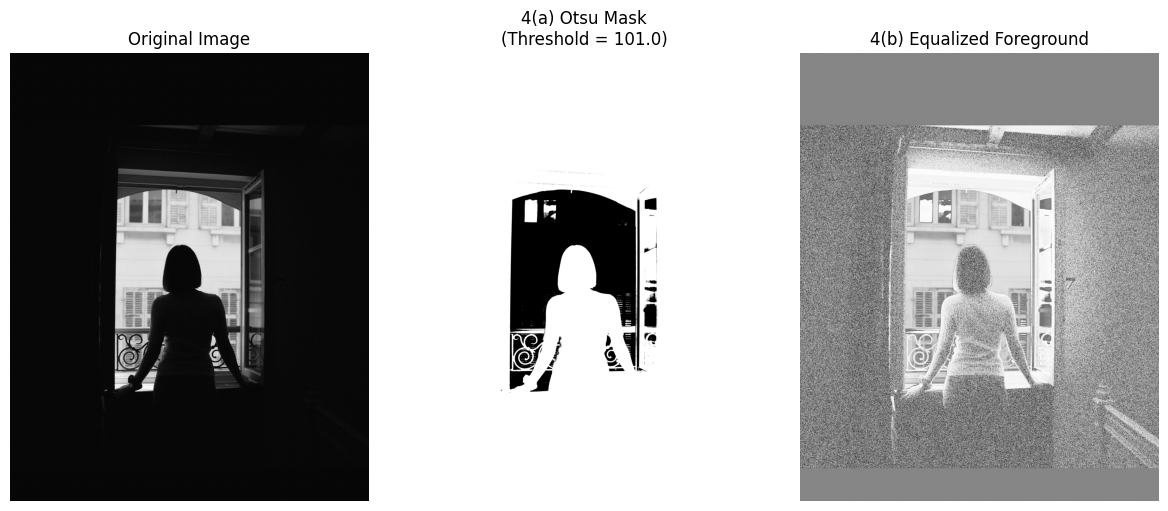

In [1]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

filename = 'looking_out.jpg'
file_path = fr"d:\computer_Vision_Inclass_11_26\{filename}"

#  Load Image
img = cv.imread(file_path, cv.IMREAD_GRAYSCALE)

if img is None:
    print(" ERROR: Image not found.")
else:
    # PART A: OTSU SEGMENTATION 
    # Apply Otsu's Thresholding (Inverse) to isolate dark foreground
    threshold_value, mask = cv.threshold(img, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    print(f" Otsu Optimal Threshold: {threshold_value}")

    # PART B: MASKED EQUALIZATION 
    # Calculate Histogram of ONLY the Foreground (using the mask)
    hist_fg = cv.calcHist([img], [0], mask, [256], [0, 256])

    #  Compute CDF for Foreground
    cdf = hist_fg.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0) # Mask zeros to avoid div by zero
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf_final = np.ma.filled(cdf_m, 0).astype('uint8')

    img_eq_temp = cv.LUT(img, cdf_final)

    # Use Mask to keep Equalized Foreground + Original Background
    foreground_part = cv.bitwise_and(img_eq_temp, img_eq_temp, mask=mask)
    background_part = cv.bitwise_and(img, img, mask=cv.bitwise_not(mask))
    final_result = cv.add(foreground_part, background_part)

    #  Display Results
    plt.figure(figsize=(12, 5))

    #  Original
    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')

    #  Part (a) Result
    plt.subplot(1, 3, 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f'4(a) Otsu Mask\n(Threshold = {threshold_value})')
    plt.axis('off')

    #  Part (b) Result
    plt.subplot(1, 3, 3)
    plt.imshow(final_result, cmap='gray')
    plt.title('4(b) Equalized Foreground')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
    